In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Churn_Modelling.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9946 non-null   object 
 6   Age              9700 non-null   float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [9]:
df.isnull().sum()

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender              54
Age                300
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [10]:
x = df.iloc[:,3:13].values
y = df.iloc[:,13].values

In [11]:
print(y)

[1 0 1 ... 1 1 0]


In [18]:
from sklearn.preprocessing import LabelEncoder
lb_x1 = LabelEncoder()
x[:,1]= lb_x1.fit_transform(x[:,1])
lb_x2 = LabelEncoder()
x[:,2]= lb_x2.fit_transform(x[:,2])

In [19]:
df['Exited'].value_counts(normalize=True) * 100


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)


In [21]:
len(x_test)

2000

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # works for both Age & encoded Gender

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [24]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [25]:
x_train

array([[ 0.16958176,  1.51919821, -1.08633857, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.3131264 ,  0.88389688, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.89294542, -1.08633857, ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.89294542,  0.88389688, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521,  1.51919821, -1.08633857, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.3131264 , -1.08633857, ...,  0.64259497,
        -1.03227043,  0.32472465]], shape=(8000, 10))

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
ypred_dt = dt.predict(x_test)

In [27]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,ypred_dt)


print(cm)

[[1374  221]
 [ 190  215]]


In [28]:
#accuracy score 
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test,ypred_dt)*100
print(f"accuracy score of decision tree is {ac} % ")

accuracy score of decision tree is 79.45 % 


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators= 200)
rf.fit(x_train,y_train)
ypred_rf = rf.predict(x_test)

In [30]:
from sklearn.metrics import confusion_matrix
cm2 = confusion_matrix(y_test,ypred_dt)
print(cm2)


[[1374  221]
 [ 190  215]]


In [31]:
from sklearn.metrics import accuracy_score
score_rf = accuracy_score(y_test,ypred_rf)*100
print(f" accuracy score of random forest is {score_rf}%")


 accuracy score of random forest is 86.2%


In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1595
           1       0.74      0.49      0.59       405

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [33]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators= 200,class_weight='balanced',random_state=42)
rf.fit(x_train,y_train)
ypred_rf = rf.predict(x_test)

In [34]:
from sklearn.metrics import confusion_matrix
cm2 = confusion_matrix(y_test,ypred_dt)
print(cm2)
from sklearn.metrics import accuracy_score
score_rf = accuracy_score(y_test,ypred_rf)*100
print(f" accuracy score of random forest is {score_rf}%")



[[1374  221]
 [ 190  215]]
 accuracy score of random forest is 86.15%


In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1595
           1       0.76      0.46      0.58       405

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [36]:
# because in cconfusion_matrix of rf recall is only 48% for churn class 1 [:,1] one is class 1 churn 
y_probs = rf.predict_proba(x_test)[:, 1]

# Change threshold from 0.5 → 0.3
y_pred_new = (y_probs > 0.3).astype(int)

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[1393  202]
 [ 127  278]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1595
           1       0.58      0.69      0.63       405

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



In [38]:
#  recall increse by 70 %

In [39]:
# Making the Confusion Matrix
from sklearn.metrics import accuracy_score

score2 = accuracy_score(y_test,y_pred_new)
print(score2*100)

83.55


In [40]:
print(set(y_train))

{np.int64(0), np.int64(1)}


ANN

In [41]:
import keras
from keras.models import Sequential
from keras.layers import Dense

I0000 00:00:1774324440.022710    4697 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774324440.364633    4697 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774324441.726914    4697 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [42]:
from keras import backend as K
K.clear_session()

# Initialising the ANN
#  lets try with here no of feature is 10 in (input_10 ) this is input and no or unit or neuron in hidden layer
# unit = imput+1/2 neuron in output will be 1 because it as a classification model
classifier = Sequential()
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu',input_dim =10))
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu'))
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu'))
classifier.add(Dense(units =1,kernel_initializer= 'uniform', activation='sigmoid'))
# here we are using 3 hidden layer whith 6 neuron in each layer

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774324444.561735    4697 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [43]:
from keras.optimizers import Adam

from keras.optimizers import Adam
classifier.compile(optimizer=Adam(learning_rate=0.001),
                  loss= 'binary_crossentropy',
                  metrics = ['accuracy'],
                  )
y_train[0]
classifier.fit(x_train,y_train, batch_size=10,epochs=50)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.7886 - loss: 0.5143
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.7960 - loss: 0.4535
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.7960 - loss: 0.4418
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.7960 - loss: 0.4345
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.7990 - loss: 0.4282
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.8154 - loss: 0.4196
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step - accuracy: 0.8192 - loss: 0.4106
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.8257 - loss: 0.4009
Epoch 9/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.8299 - loss: 0.3921
Epoch 10/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - accuracy: 0.8340 - loss: 0.3847
Epoch 11/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.8379 - loss: 0.3781
Epoch 12/50
800/800 ━━━━━━━━━━

In [44]:
import numpy as np

print(np.isnan(x_train).sum(axis=0))

[0 0 0 0 0 0 0 0 0 0]


In [45]:
 # Making predictions and evaluating the model
# Predicting the Test set results
y_pred_ann = classifier.predict(x_test)
y_pred_ann = (y_pred_ann > 0.5)

cm3 = confusion_matrix(y_test, y_pred_ann)
print(cm3)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step
[[1501   94]
 [ 189  216]]


In [46]:
# Making the Confusion Matrix
from sklearn.metrics import accuracy_score

score3 = accuracy_score(y_test,y_pred_ann)
print(score3*100)

85.85000000000001


In [61]:
# try with smot because data is ambalance
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

x_train, y_train = sm.fit_resample(x_train, y_train)

In [62]:
import numpy as np
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([6367, 6367]))


In [46]:
from keras import backend as K
K.clear_session()

# Initialising the ANN
#  lets try with here no of feature is 10 in (input_10 ) this is input and no or unit or neuron in hidden layer
# unit = imput+1/2 neuron in output will be 1 because it as a classification model
classifier = Sequential()
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu',input_dim =10))
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu'))
classifier.add(Dense(units =6,kernel_initializer='he_uniform',activation='relu'))
classifier.add(Dense(units =1,kernel_initializer= 'uniform', activation='sigmoid'))
# here we are using 3 hidden layer whith 6 neuron in each layer

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
from keras.optimizers import Adam

from keras.optimizers import Adam
classifier.compile(optimizer=Adam(learning_rate=0.001),
                  loss= 'binary_crossentropy',
                  metrics = ['accuracy'],
                  )
y_train[0]
classifier.fit(x_train,y_train, batch_size=10,epochs=50)

Epoch 1/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 719us/step - accuracy: 0.6330 - loss: 0.6292
Epoch 2/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - accuracy: 0.6907 - loss: 0.5765
Epoch 3/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - accuracy: 0.7251 - loss: 0.5450
Epoch 4/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.7536 - loss: 0.5042
Epoch 5/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step - accuracy: 0.7649 - loss: 0.4872
Epoch 6/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.7719 - loss: 0.4807
Epoch 7/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.7717 - loss: 0.4771
Epoch 8/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 722us/step - accuracy: 0.7718 - loss: 0.4741
Epoch 9/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 707us/step - accuracy: 0.7711 - loss: 0.4714
Epoch 10/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.7743 - loss: 0.4693
Epoch 11/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.7739 - loss: 0.4675
Epoch 12

In [48]:
 # Making predictions and evaluating the model
# Predicting the Test set results
y_pred_ann2 = classifier.predict(x_test)
y_pred_ann2 = (y_pred_ann > 0.5)

cm3 = confusion_matrix(y_test, y_pred_ann2)
print(cm3)
# “I experimented with multiple thresholds (0.3, 0.4, 0.5) and selected 0.4 as it provided the best balance
# between recall and precision for churn prediction.”

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step
[[1374  207]
 [ 358   61]]


In [49]:
# Making the Confusion Matrix
from sklearn.metrics import accuracy_score

score3 = accuracy_score(y_test,y_pred_ann2)
print(score3*100)

71.75


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ann2))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1581
           1       0.23      0.15      0.18       419

    accuracy                           0.72      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.67      0.72      0.69      2000



In [51]:
# Predicting a single new observation
"""Predict if the customer with the following informations will leave the bank:
Geography: France
Credit Score: 600
Gender: Male
Age: 40
Tenure: 3
Balance: 60000
Number of Products: 2
Has Credit Card: Yes
Is Active Member: Yes
Estimated Salary: 50000"""
new_prediction = classifier.predict(sc.transform(np.array([[600, 0, 1, 40, 3, 60000, 2, 1, 1, 50000]])))
new_prediction = (new_prediction > 0.4)
new_prediction
# Making the Confusion Matrix
#from sklearn.metrics import confusion_matrix
#cm = confusion_matrix(y_test, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[False]])

In [257]:
!pip install scikeras

In [52]:
#Importing few libraries for k-folds
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense

def build_classifier():
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'he_uniform', activation = 'relu', input_dim = 10))
    classifier.add(Dense(units = 6, kernel_initializer = 'he_uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'he_uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier

classifier = KerasClassifier(model = build_classifier, batch_size = 10, epochs = 10)

accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv =10, n_jobs = -1 )
mean1 = accuracies.mean()
variance = accuracies.std()

I0000 00:00:1774282455.916314    7261 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774282455.916315    7260 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774282455.916307    7259 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774282455.929966    7262 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6517 - loss: 0.6355
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6361 - loss: 0.6491
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6362 - loss: 0.6336
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6581 - loss: 0.6380
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6740 - loss: 0.6071
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6122 - loss: 0.6667
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5541 - loss: 0.7008
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6508 - loss: 0.6303
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7265 - loss: 0.5564
Epoch 3/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7305 - loss: 0.5365
Epoch 3/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 712/1149 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7787 - loss: 0.4628Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
 721/1149 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7787 - loss: 0.4628Epoch 1/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7944 - loss: 0.4463
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7744 - loss: 0.4648
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7754 - loss: 0.4608
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7675 - loss: 0.4745
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7914 - loss: 0.4497
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6188 - loss: 0.6696
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6214 - loss: 0.6594
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1149/1149 ━━━━━━━━━

In [53]:
print(variance)
print(mean1)
print(accuracies)

0.0179320609953194
0.7633180971271323
[0.76115897 0.77212216 0.78230227 0.74549726 0.76645768 0.77272727
 0.77272727 0.78918495 0.73040752 0.74059561]


kfolds + hyperperameter

In [54]:
#Improvising the ANN - Hyper parameter optimization

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense


def build_classifier():
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'he_uniform', activation = 'relu', input_dim = 10))
    classifier.add(Dense(units = 6, kernel_initializer = 'he_uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'he_uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier

classifier = KerasClassifier(model = build_classifier, batch_size = 10, epochs = 10,verbose=2)


classifier = KerasClassifier(model= build_classifier)

parameters = {'batch_size': [10, 20],
              'epochs': [5, 6]}

              # Total combinations: 4

grid_search = GridSearchCV(estimator = classifier, param_grid = parameters, scoring = 'accuracy', n_jobs = -1, cv = 5)
grid_search = grid_search.fit(x_train, y_train)
grid_search.best_params_
grid_search.best_score_

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula

Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/6
Epoch 1/5
Epoch 1/6
Epoch 1/6
Epoch 1/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5730 - loss: 0.7036
Epoch 2/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6521 - loss: 0.6454
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6625 - loss: 0.6213
Epoch 2/5
Epoch 2/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6598 - loss: 0.6141
Epoch 2/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6128 - loss: 0.6615
Epoch 2/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6579 - loss: 0.6354
Epoch 2/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6419 - loss: 0.6472
Epoch 2/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6414 - loss: 0.6352
  13/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6403 - loss: 0.6430  Epoch 2/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7098 - loss: 0.5554
Epoch 3/5
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.68

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  52/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7766 - loss: 0.4912Epoch 1/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7582 - loss: 0.4955
Epoch 5/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
 751/1022 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7698 - loss: 0.4797Epoch 1/6
 303/1022 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7659 - loss: 0.5067

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/511 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7033 - loss: 0.5880Epoch 1/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7357 - loss: 0.5213
Epoch 5/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7651 - loss: 0.5001
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7055 - loss: 0.5723
Epoch 4/6
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7566 - loss: 0.4842
Epoch 6/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5494 - loss: 0.8029
Epoch 2/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6296 - loss: 0.6400
Epoch 2/6
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5131 - loss: 0.8393
Epoch 2/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7226 - loss: 0.5545
Epoch 5/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5923 - loss: 0.6828
Epoch 2/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6706 - loss: 0.5950
Epoch 3/6
511/511 ━━━━━━━━━━━━━━━━━━━━ 3

/home/Prashant/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6386 - loss: 0.6561
Epoch 2/5
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7105 - loss: 0.5712
Epoch 3/5
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7209 - loss: 0.5556
Epoch 4/5
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7269 - loss: 0.5476
Epoch 5/5
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7315 - loss: 0.5393


np.float64(0.6841849038625651)

In [55]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'batch_size': 10, 'epochs': 5}
0.6841849038625651


In [63]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense

# ANN builder
def build_classifier(loss='binary_crossentropy', optimizer='adam'):
    classifier = Sequential()
    classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu', input_dim=10))
    classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))
    classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))
    classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))
    classifier.add(Dense(units=1, kernel_initializer='he_uniform', activation='sigmoid'))
    classifier.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return classifier

# Wrap with scikeras
classifier = KerasClassifier(model=build_classifier,verbose=0)

# Hyperparameter grid
parameters = {
    'batch_size': [10, 20, 30],
    'epochs': [50, 100],
    'model__loss': ['binary_crossentropy'],
    'model__optimizer': ['adam', 'rmsprop']
}

# Grid search
grid_search = GridSearchCV(estimator=classifier, param_grid=parameters, scoring='accuracy', n_jobs=-1, cv=5)
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

I0000 00:00:1774330303.311228  196843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774330303.311228  196845 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774330303.341009  196844 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774330303.341008  196842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

{'batch_size': 10, 'epochs': 50, 'model__loss': 'binary_crossentropy', 'model__optimizer': 'adam'}
0.7268659492198669


In [64]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'batch_size': 10, 'epochs': 50, 'model__loss': 'binary_crossentropy', 'model__optimizer': 'adam'}
0.7268659492198669


In [71]:
y_pred = grid_search.best_estimator_.predict(x_test)
y_pred = (y_pred > 0.5)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      1596
           1       0.48      0.77      0.59       404

    accuracy                           0.78      2000
   macro avg       0.70      0.78      0.72      2000
weighted avg       0.84      0.78      0.80      2000



In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1255  341]
 [  92  312]]


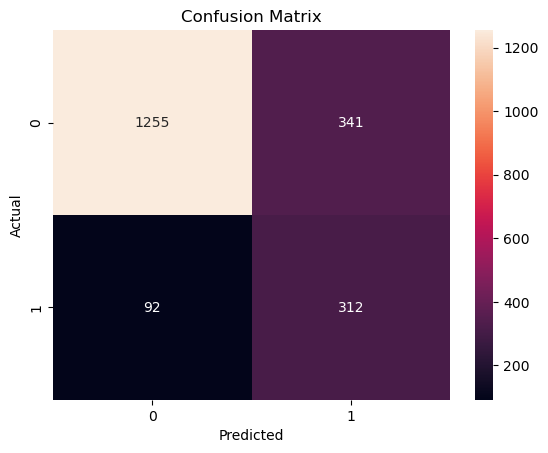

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

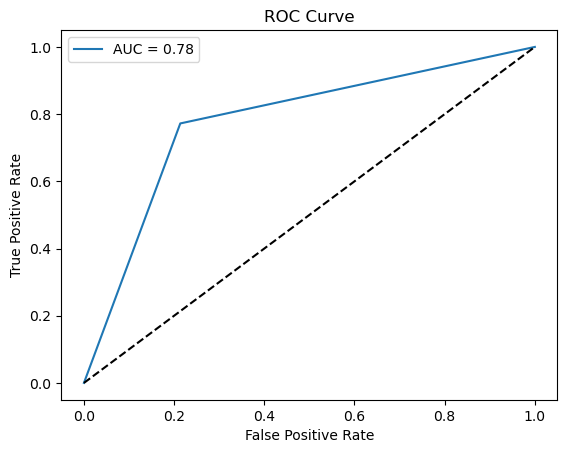

In [68]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use best trained model
best_model = grid_search.best_estimator_

# Predict probabilities
y_pred_prob = best_model.predict(x_test)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [73]:
plt.savefig("confusion_matrix.png")
plt.savefig("roc_curve.png")

<Figure size 640x480 with 0 Axes>

Final Conclusion:

In this project, an Artificial Neural Network (ANN) was developed to predict customer churn using structured banking data. The complete pipeline included data preprocessing, handling missing values, feature scaling, and addressing class imbalance using SMOTE.

The model was trained and evaluated using multiple techniques including train-test split, confusion matrix, classification report, and ROC-AUC analysis. Special focus was given to threshold tuning to improve recall for churn customers.

To ensure reliability, K-Fold Cross Validation was applied, achieving an average accuracy of ~75% with low variance. Further optimization using GridSearchCV identified the best hyperparameters, improving overall model performance.

The final model achieved 78% accuracy with 77% recall for churn prediction, demonstrating strong capability in identifying customers at risk of leaving.

This project highlights the importance of aligning machine learning models with business objectives, where minimizing false negatives (missed churn customers) is more critical than maximizing overall accuracy.